In [ ]:
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

from vasae.models.factory import get_blackbox_model
from vasae.models.sae_hf import SAEConfig, SAEModel


/home/b5bq/pu22650.b5bq/miniforge3/envs/qwen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
device = "cuda"
sae_cfg = SAEConfig(
    dim_input=768, 
    dim_sparse=50257, 
    sparsity_type="topk", 
    k=8, 
    tied_decoder=True,
)

# Utils

In [ ]:
def clip_cmap(base_cmap, lo=0.1, hi=0.75, n=256):
    # 把最深和最浅的颜色去掉
    colors = base_cmap(np.linspace(lo, hi, n))
    return LinearSegmentedColormap.from_list(
        f"{base_cmap.name}_clip", colors
    )

cmap = clip_cmap(plt.cm.Blues, lo=0.08, hi=0.75)

In [ ]:


def plot_logit_lens_lists(
    tokens_by_layer,   # NDArray[L][S]
    probs_by_layer,    # NDArray[L][S]
    x_tokens,
    title=None,
    fontsize=9,
    dpi=300,
    cbar_ticks=(0,0.2,0.4,0.6,0.8,1),
):
    
    Z = probs_by_layer[::-1]    # 高层在上
    T = tokens_by_layer[::-1]

    H, W = Z.shape
    y_labels = list(range(1, len(tokens_by_layer)+1))[::-1] # 显示layer从1开始


    fig_w = max(1.2, 0.9 * W)
    fig_h = max(1.2, 0.45 * H)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    norm = mcolors.Normalize(0, 1)
    cmap = clip_cmap(plt.cm.Blues, lo=0.1, hi=0.7)

    im = ax.imshow(
        Z,
        cmap=cmap,
        norm=norm,
        interpolation="none",
        aspect="auto",
        origin="upper",
    )

    # cell text
    for i in range(H):
        for j in range(W):
            ax.text(
                j, i, T[i, j],
                ha="center", va="center",
                fontsize=fontsize,
            )

    # x axis
    ax.set_xticks(range(W))
    ax.set_xticklabels(x_tokens, fontsize=fontsize)
    ax.tick_params(axis="x", pad=4)

    # y axis
    yt = np.linspace(0, H-1, min(6, H), dtype=int)
    ax.set_yticks(yt)
    ax.set_yticklabels([y_labels[i] for i in yt], fontsize=fontsize)

    # clean
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

    if title:
        ax.set_title(title, fontsize=fontsize+1, pad=6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_ticks(cbar_ticks)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.tight_layout(rect=[0,0,0.97,1])
    plt.show()

# Main

In [ ]:
saes: List[SAEModel] = []
for layer_i in range(0, 12):
    sae = SAEModel(sae_cfg)
    sae._tied_embedding = nn.Embedding(50257, 768) # TODO: 这个设计会使得加载变得困难
    sae.load_state_dict(torch.load(f"/scratch/b5bq/pu22650.b5bq/VASAE_out/ablation/vasae/vasae_topk/vasae_topk_l{layer_i}.pth"))
    sae = sae.eval().to(device)
    saes.append(sae)

In [7]:
model, tokenizer = get_blackbox_model("gpt2", "cuda")

In [ ]:
def z_to_res_top1(z: torch.Tensor):
    # z: [B, S, V]，视作 token scores/logits
    probs = F.softmax(z, dim=-1)                 # [B,S,V]
    token_probs, token_ids = probs.max(dim=-1)   # [B,S]
    # 变成你代码用的格式：token_ids[0,s] / token_probs[0,s]
    return {
        "token_ids": token_ids,     # [B,S]
        "token_probs": token_probs  # [B,S]
    }

In [9]:
text = "my name is Bryan, I am a huge fan of yours. I was always very impressed with you"
tokens = tokenizer(
    text,
    return_tensors="pt",
    max_length=64,
    truncation=True,
    padding="max_length",
    # return_offsets_mapping=True,  # 保存原始位置(start, end)
    add_special_tokens=True,
).to("cuda")

with torch.no_grad():
    out = model(**tokens, output_hidden_states=True,)

In [ ]:
# 单独收集h0
token_ids = tokens["input_ids"][0].detach().cpu().tolist()
x_tokens = [tokenizer.decode(token_ids[s]) for s in range(len(token_ids))]

In [ ]:
pred_tokens_per_layer = []
pred_probs_per_layer = []
with torch.no_grad():
    for layer_i, a_l in enumerate(out.hidden_states):
        if layer_i == 0: # layer 0 is embedding 单独收集过了
            continue 
        _, z = saes[layer_i-1].encode(a_l)
        # get top1 for visualize
        res = z_to_res_top1(z.detach().cpu())
        pred_tokens_per_layer.append([tokenizer.decode(res["token_ids"][0, s]) for s in range(res["token_ids"].size(1))]) # 假设只有一个batch
        pred_probs_per_layer.append(res["token_probs"][0].detach().cpu().tolist())

# 只显示前8个
pred_tokens_per_layer = np.array(pred_tokens_per_layer)[:,:8]
pred_probs_per_layer = np.array(pred_probs_per_layer)[:, :8]
x_tokens = np.array(x_tokens)[:8]

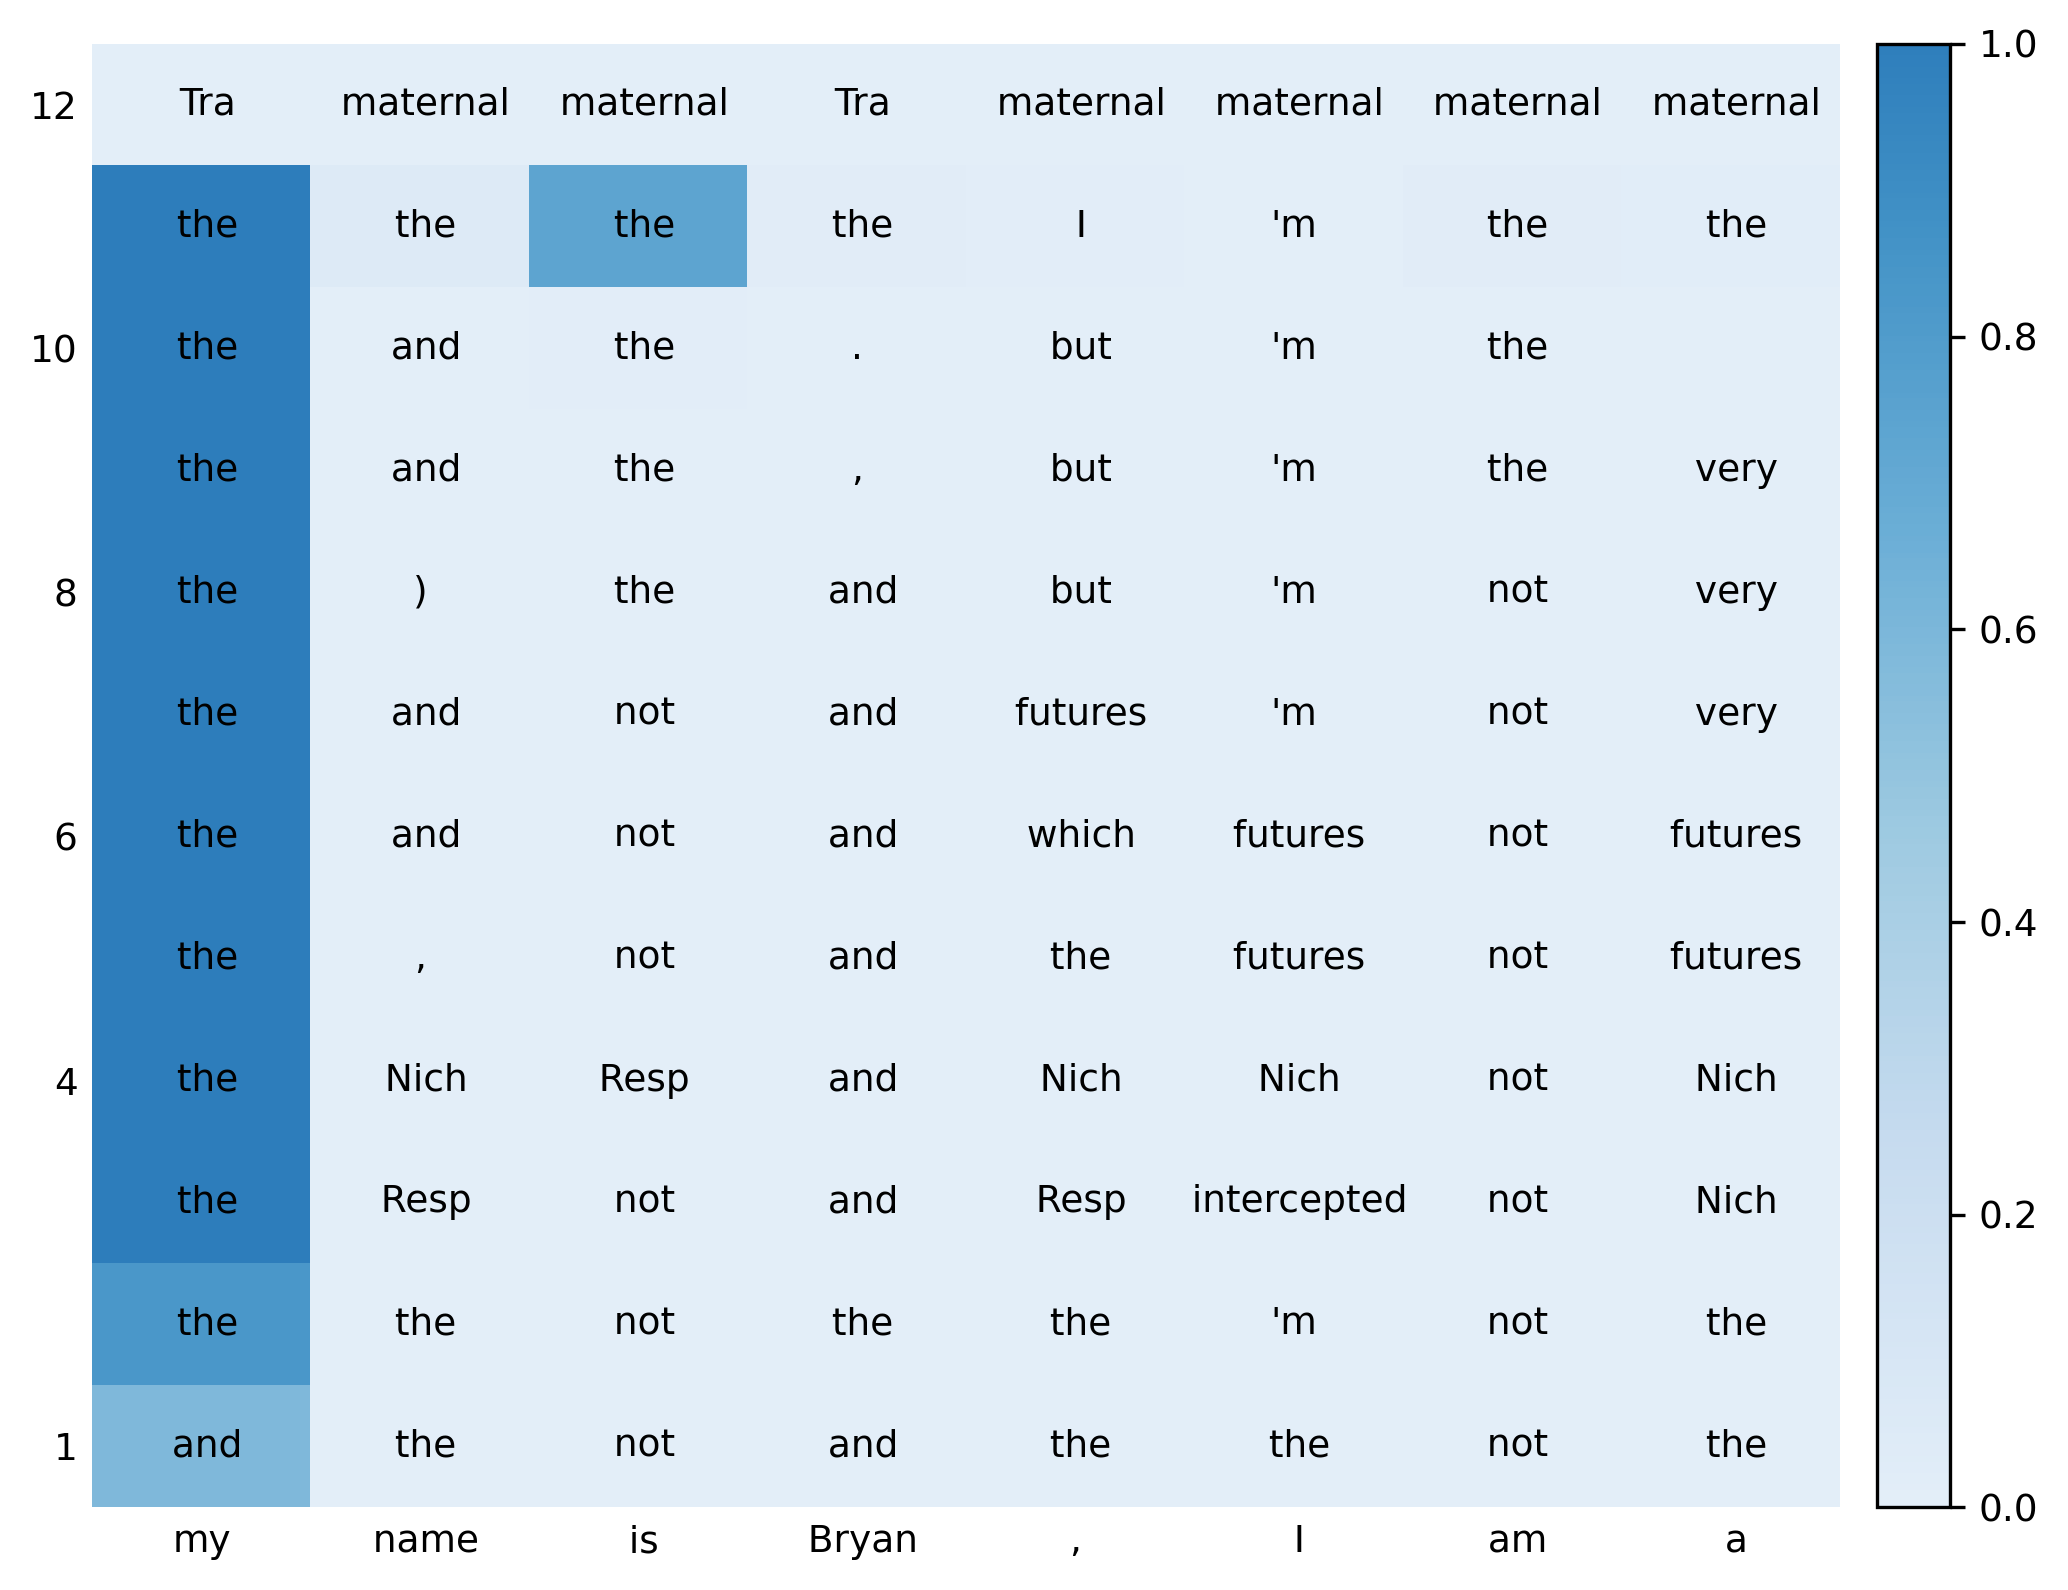

In [ ]:
plot_logit_lens_lists(pred_tokens_per_layer, pred_probs_per_layer, x_tokens)